In [2]:
''' imports libraries '''

# misc
import pandas as pd # Import Pandas for data manipulation using dataframes
import numpy as np # Import Numpy for data statistical analysis 
import matplotlib.pyplot as plt # Import matplotlib for data visualisation
import seaborn as sns
import random

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Keras
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

# FEATURE ENGINEERING

In [4]:
''' defines functions for feature transformation '''

def one_hot_encode(feature):
    global df_enabled

    if not feature in df_enabled.columns: 
        print(f'WARN: tried to one-hot encode missing feature {feature}')
        return

    # prefix appends feature name to each categorie's column
    one_hot = pd.get_dummies(df_enabled[feature], prefix=feature)

    # adds one boolean column for each discrete value
    df_enabled = pd.concat([df_enabled, one_hot], axis=1)

    # drops previous column
    df_enabled.drop(feature, axis=1, inplace=True)


# note - uses mean normalisation
def normalise(feature):
    global df_enabled

    if not feature in df_enabled.columns: 
        print(f'WARN: tried to normalise missing feature {feature}')
        return

    feature_row = df_enabled[feature]
    df_enabled[f'{feature}'] = (feature_row - feature_row.mean()) / (feature_row.max() - feature_row.min())
    df_enabled.rename(columns={feature: f'{feature}_normalised'}, inplace=True)
    

In [5]:
''' dataframes creation for both training and testing datasets '''

df = pd.read_csv('data/dataset_sample.csv',sep=',')

# selects features
enabled_features = [
    'merchant_category', 
    'merchant_type', 
    'country', 
    'currency', 
    'city_size', 
    'amount', 
    'distance_from_home', 
    'transaction_hour',
    'weekend_transaction',
    'high_risk_merchant',
    'card_type'
]
df_enabled = df[enabled_features].copy()

# normalises features
for feature in ['amount', 'distance_from_home', 'transaction_hour']:
    normalise(feature)

# one-hot encodes features
for feature in ['merchant_category', 'merchant_type', 'country', 'currency', 'city_size', 'card_type']:
    one_hot_encode(feature)

# adds the label to the last position
df_enabled['is_fraud'] = df['is_fraud']

# prints overview
print(df_enabled.shape)
print(df_enabled.columns)

# throws if is_fraud column is not last
if df_enabled.columns[-1] != 'is_fraud':
    raise Exception('Invalid label-column')

# throws if unhandled null-values
sum_of_nulls = df_enabled.isnull().sum().sum()
if sum_of_nulls > 0: 
    raise Exception(f'{sum_of_nulls} unhandled null-values')

# note - random_state is the seed for shuffling
df_train, df_test = train_test_split(df_enabled, test_size=0.3, random_state=42)

(10000, 61)
Index(['amount_normalised', 'distance_from_home_normalised',
       'transaction_hour_normalised', 'weekend_transaction',
       'high_risk_merchant', 'merchant_category_Education',
       'merchant_category_Entertainment', 'merchant_category_Gas',
       'merchant_category_Grocery', 'merchant_category_Healthcare',
       'merchant_category_Restaurant', 'merchant_category_Retail',
       'merchant_category_Travel', 'merchant_type_airlines',
       'merchant_type_booking', 'merchant_type_casual', 'merchant_type_events',
       'merchant_type_fast_food', 'merchant_type_gaming',
       'merchant_type_hotels', 'merchant_type_local', 'merchant_type_major',
       'merchant_type_medical', 'merchant_type_online',
       'merchant_type_pharmacy', 'merchant_type_physical',
       'merchant_type_premium', 'merchant_type_streaming',
       'merchant_type_supplies', 'merchant_type_transport',
       'country_Australia', 'country_Brazil', 'country_Canada',
       'country_France', 'coun

In [6]:
df_train.head()

,amount_normalised,distance_from_home_normalised,transaction_hour_normalised,weekend_transaction,high_risk_merchant,merchant_category_Education,merchant_category_Entertainment,merchant_category_Gas,merchant_category_Grocery,merchant_category_Healthcare,...,currency_SGD,currency_USD,city_size_large,city_size_medium,card_type_Basic Credit,card_type_Basic Debit,card_type_Gold Credit,card_type_Platinum Credit,card_type_Premium Debit,is_fraud
9069,-0.009884,-0.3212,-0.179674,True,False,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2603,-0.009966,0.6788,-0.353587,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
7738,-0.006370,0.6788,-0.266630,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
1579,-0.009852,0.6788,-0.440543,False,False,True,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
5058,-0.009819,0.6788,0.081196,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,True


In [7]:
# Create training and testing arrays
training = np.array(df_train, dtype = 'float32')
testing = np.array(df_test, dtype='float32')

# TRAINING THE MODEL

In [9]:
# Prepare the training and testing dataset 
X_train = training[:,:-1]
y_train = training[:,-1:]

X_test = testing[:,:-1]
y_test = testing[:,-1:]

In [10]:
# validation dataset that might used to help the model to generalize
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size = 0.2, random_state = 32415)

In [11]:
X_train.shape

(5600, 60)

In [12]:
X_test.shape

(3000, 60)

In [13]:
X_validate.shape

(1400, 60)

In [14]:
y_test.sum()

617.0

In [15]:
model = Sequential([
    Dense(90, activation='relu'),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss=keras.losses.binary_crossentropy, metrics=['accuracy'])

# note - reduces false negatives
class_weights = compute_class_weight('balanced', classes=np.unique(y_validate), y=y_validate[:, 0])
class_weights_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_validate, y_validate), 
    epochs=15, batch_size=128, 
    class_weight=class_weights_dict
)

Epoch 1/15


2024-11-16 16:56:01.826333: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


44/44 [==============================] - 0s 2ms/step - loss: 0.5805 - accuracy: 0.7636 - val_loss: 0.4172 - val_accuracy: 0.8757
Epoch 2/15
44/44 [==============================] - 0s 983us/step - loss: 0.3368 - accuracy: 0.8752 - val_loss: 0.3099 - val_accuracy: 0.8679
Epoch 3/15
44/44 [==============================] - 0s 1ms/step - loss: 0.3003 - accuracy: 0.8737 - val_loss: 0.2795 - val_accuracy: 0.8836
Epoch 4/15
44/44 [==============================] - 0s 1ms/step - loss: 0.2968 - accuracy: 0.8779 - val_loss: 0.2762 - val_accuracy: 0.8857
Epoch 5/15
44/44 [==============================] - 0s 1ms/step - loss: 0.2928 - accuracy: 0.8775 - val_loss: 0.2928 - val_accuracy: 0.8786
Epoch 6/15
44/44 [==============================] - 0s 1ms/step - loss: 0.2827 - accuracy: 0.8789 - val_loss: 0.2998 - val_accuracy: 0.8771
Epoch 7/15
44/44 [==============================] - 0s 1ms/step - loss: 0.2809 - accuracy: 0.8770 - val_loss: 0.2735 - val_accuracy: 0.8900
Epoch 8/15
44/44 [===========

# EVALUATING THE MODEL

In [17]:
print('Last validation accuracy:')
last_epoch_accuracy = history.history['val_accuracy'][-1]
print(f'{last_epoch_accuracy:.4f}')
print('Test accuracy:')
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

Last validation accuracy:
0.8743
Test accuracy:
94/94 [==============================] - 0s 308us/step - loss: 0.3179 - accuracy: 0.8677


In [18]:
y_pred = model.predict(X_test)
predicted_classes = (y_pred > 0.5).astype(int)

94/94 [==============================] - 0s 282us/step


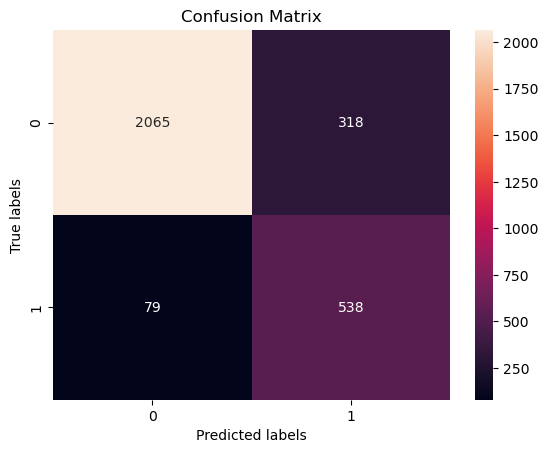

Correct guesses: 2603 out of 3000


In [19]:
# use seaborn library to plot the confusion matrix 
matrix = confusion_matrix(y_test, predicted_classes)

sns.heatmap(matrix, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Sum the diagonal element to get the total true correct values
identity = np.eye(matrix.shape[0])
diagonal = np.multiply(matrix, identity)
sum_correct = np.sum(diagonal)
sum_total = np.sum(matrix)
print(f'Correct guesses: {sum_correct:.0f} out of {sum_total:.0f}')

In [20]:
target_names = ["Class {}".format(i) for i in range(2)]
print(classification_report(y_test, predicted_classes, target_names = target_names))

              precision    recall  f1-score   support

     Class 0       0.96      0.87      0.91      2383
     Class 1       0.63      0.87      0.73       617

    accuracy                           0.87      3000
   macro avg       0.80      0.87      0.82      3000
weighted avg       0.89      0.87      0.87      3000

